In [11]:
import numpy as np
import matplotlib.pyplot as plt
from layers import Sigmoid, Affine, SoftmaxWithLoss

In [8]:
N = 1
H = 1
T = 20

dh = np.ones((N, H))
np.random.seed(3)


[[1.78862847]]


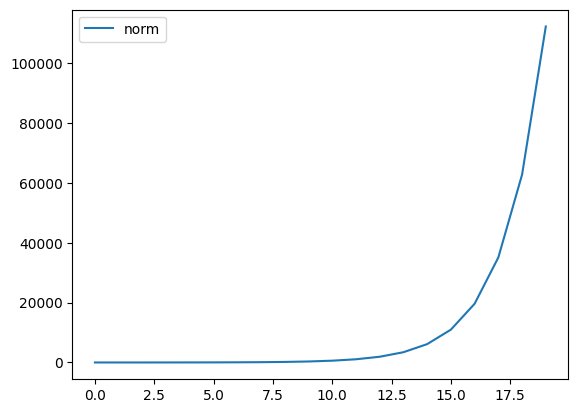

In [6]:
Wh = np.random.randn(H, H)
print(Wh)

norm_list = []
for t in range(T):
    dh = np.matmul(dh, Wh.T)
    norm_list.append(dh)

norm_list
# norm_list 시각화
norm = np.array(norm_list)
norm = np.squeeze(norm)
plt.plot(norm, label='norm')
plt.legend()
plt.show()

[[0.89431424]]


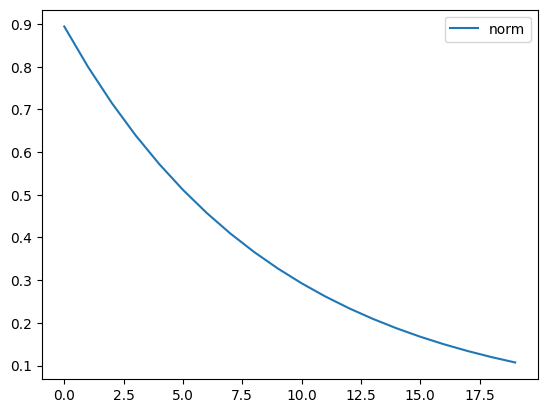

In [9]:
Wh = np.random.randn(H, H) * 0.5 # 가중치를 0.5배로 줄임
print(Wh)

norm_list = []
for t in range(T):
    dh = np.matmul(dh, Wh.T)
    norm_list.append(dh)

norm = np.array(norm_list)
norm = np.squeeze(norm)
plt.plot(norm, label='norm')
plt.legend()
plt.show()

### LSTM 계층  

In [12]:
class LSTM:
  def __init(self,Wx,Wh,b):
    self.params = [Wx,Wh,b] # 가중치에는 4개분의 가중치가 담겨 있다. input gate, forget gate, output gate, block input의 가중치 4개
    self.grads = [np.zeros_like(Wx),np.zeros_like(Wh),np.zeros_like(b)] # 기울기를 저장하는 grads 인스턴스 변수 초기화
    self.cache = None       # 순전파시 중간 결과를 담을 cache변수로 역전파 계산에 사용하는 인스턴스 변수 cache를 초기화
  
  # 순전파
  def forward(self, x, h_prev, c_prev): # x는 입력 데이터, h_prev는 이전 시각의 은닉 상태, c_prev는 이전 시각의 기억 셀
    Wx, Wh, b = self.params
    N, H = h_prev.shape

    A = np.matmul(x, Wx) + np.matmul(h_prev, Wh) + b  # 4개의 가중치를 모아 아핀 변환을 수행하여 A를 계산

    f = A[:, :H]
    g = A[:, H:2*H]
    i = A[:, 2*H:3*H]
    o = A[:, 3*H:]

    f = Sigmoid(f)                # forget gate
    g = np.tanh(g)                # 새로운 정보를 기억하기 위한 input
    i = Sigmoid(i)                # input gate
    o = Sigmoid(o)                # output gate

    c_next = f * c_prev + g * i   # 기억 셀(memory cell) 계산, c_next = f * c_prev + g * i
    h_next = o * np.tanh(c_next)  # 은닉 상태 계산, h_next = o * tanh(c_next)

    self.cache = (x, h_prev, c_prev, i, f, g, o, c_next)
    return h_next, c_next
  
  # 역전파
  def backward(self, dh_next, dc_next):
    Wx, Wh, b = self.params
    x, h_prev, c_prev, i, f, g, o, c_next = self.cache

    tanh_c_next = np.tanh(c_next)

    ds = dc_next + (dh_next * o) * (1 - tanh_c_next ** 2)

    dc_prev = ds * f

    di = ds * g
    df = ds * c_prev
    do = dh_next * tanh_c_next
    dg = ds * i

    di *= i * (1 - i)
    df *= f * (1 - f)
    do *= o * (1 - o)
    dg *= (1 - g ** 2)

    dA = np.hstack((df, dg, di, do))

    dWh = np.dot(h_prev.T, dA)
    dWx = np.dot(x.T, dA)
    db = dA.sum(axis=0)

    self.grads[0][...] = dWx
    self.grads[1][...] = dWh
    self.grads[2][...] = db

    dx = np.dot(dA, Wx.T)
    dh_prev = np.dot(dA, Wh.T)

    return dx, dh_prev, dc_prev

### Time LSTM 계층    

In [13]:
# T개 분의 시계열 데이터를 한꺼번에 처리하는 TimeLSTM 계층
class TimeLSTM:
  def __init__(self, Wx, Wh, b , stateful=False):
    self.params = [Wx, Wh, b]
    self.grads = [np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(b)]
    self.layers = None

    self.h, self.c = None, None
    self.dh = None
    self.stateful = stateful
  
  def forward(self, xs):
    Wx, Wh, b = self.params
    N, T, D = xs.shape
    H = Wh.shape[0]

    self.layers = []
    hs = np.empty((N, T, H), dtype='f')

    if not self.stateful or self.h is None:
      self.h = np.zeros((N, H), dtype='f')
    if not self.stateful or self.c is None:
      self.c = np.zeros((N, H), dtype='f')
    
    for t in range(T):
      layer = LSTM(*self.params)
      self.h, self.c = layer.forward(xs[:, t, :], self.h, self.c)
      hs[:, t, :] = self.h

      self.layers.append(layer)
    
    return hs
  
  def backward(self, dhs):
    Wx, Wh, b = self.params
    N, T, H = dhs.shape
    D = Wx.shape[0]

    dxs = np.empty((N, T, D), dtype='f')
    dh, dc = 0, 0

    grads = [0, 0, 0]
    for t in reversed(range(T)):
      layer = self.layers[t]
      dx, dh, dc = layer.backward(dhs[:, t, :] + dh, dc)
      dxs[:, t, :] = dx
      for i, grad in enumerate(layer.grads):
        grads[i] += grad
    
    for i, grad in enumerate(grads):
      self.grads[i][...] = grad
    self.dh = dh
    return dxs
  
  def set_state(self, h, c=None):
    self.h, self.c = h, c
    
  def reset_state(self):
    self.h, self.c = None, None

In [15]:
import pickle
from time_layers import TimeEmbedding, TimeAffine, TimeSoftmaxWithLoss

In [ ]:
class Rnnlm:
  def __init__(self, vocab_size=10000, wordvec_size=100, hidden_size=100):
      V, D, H = vocab_size, wordvec_size, hidden_size
      rn = np.random.randn

      # 가중치 초기화
      embed_W = (rn(V, D) / 100).astype('f')
      lstm_Wx = (rn(D, 4 * H) / np.sqrt(D)).astype('f')
      lstm_Wh = (rn(H, 4 * H) / np.sqrt(H)).astype('f')
      lstm_b = np.zeros(4 * H).astype('f')
      affine_W = (rn(H, V) / np.sqrt(H)).astype('f')
      affine_b = np.zeros(V).astype('f')

      # 계층 생성
      self.layers = [
          TimeEmbedding(embed_W),
          TimeLSTM(lstm_Wx, lstm_Wh, lstm_b, stateful=True),
          TimeAffine(affine_W, affine_b)
      ]
      self.loss_layer = TimeSoftmaxWithLoss()
      self.lstm_layer = self.layers[1]

      # 모든 가중치와 기울기를 리스트에 모은다.
      self.params, self.grads = [], []
      for layer in self.layers:
          self.params += layer.params
          self.grads += layer.grads

  def predict(self, xs):
      for layer in self.layers:
          xs = layer.forward(xs)
      return xs

  def forward(self, xs, ts):
      score = self.predict(xs)
      loss = self.loss_layer.forward(score, ts)
      return loss

  def backward(self, dout=1):
      dout = self.loss_layer.backward(dout)
      for layer in reversed(self.layers):
          dout = layer.backward(dout)
      return dout

  def reset_state(self):
      self.lstm_layer.reset_state()